<a href="https://colab.research.google.com/github/cjmunoz131/03MAIR---Algoritmos-de-Optimizacion/blob/main/Trabajo_Pr%C3%A1ctico_Final_AlgoritmosOptimizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: César James Muñoz Martinez  <br>
Url: https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---/tree/master/TrabajoPractico<br>
Google Colab: https://colab.research.google.com/drive/16IB6VnjQza3eAD0TJEEJ7Qbx-cfejJb5 <br>
Problema:
>1. Sesiones de doblaje <br>
>2. Organizar los horarios de partidos de una jornada de La Liga<br>
>3. Configuración de Tribunales

Descripción del problema:

Problema 2: Organizar los horarios de partidos de La Liga
* Desde la La Liga de fútbol profesional se pretende organizar los horarios de los partidos de liga de cada jornada. Se conocen algunos datos que nos deben llevar a diseñar un algoritmo que realice la asignación de los partidos a los horarios de forma que maximice la audiencia.
* Los horarios disponibles se conocen a priori y son los siguientes:

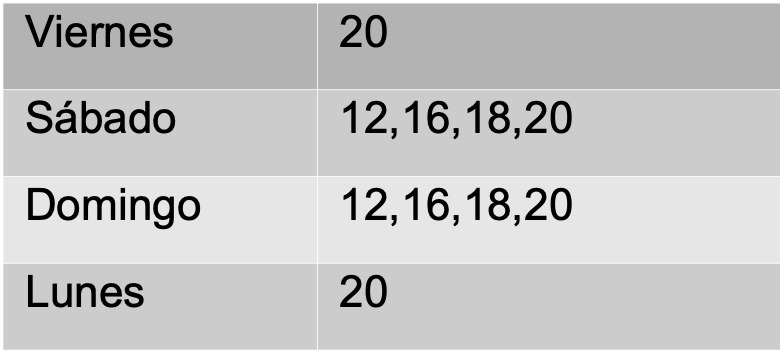


* En primer lugar se clasifican los equipos en tres categorías según el número de seguidores (que tiene relación directa con la audiencia). Hay **3 equipos** en la **categoría A, 11 equipos de categoría B y 6 equipos de categoría C**.

* Se conoce estadísticamente la audiencia que genera cada partido según los equipos que se enfrentan y en horario de sábado a las 20h (el mejor en todos los casos)

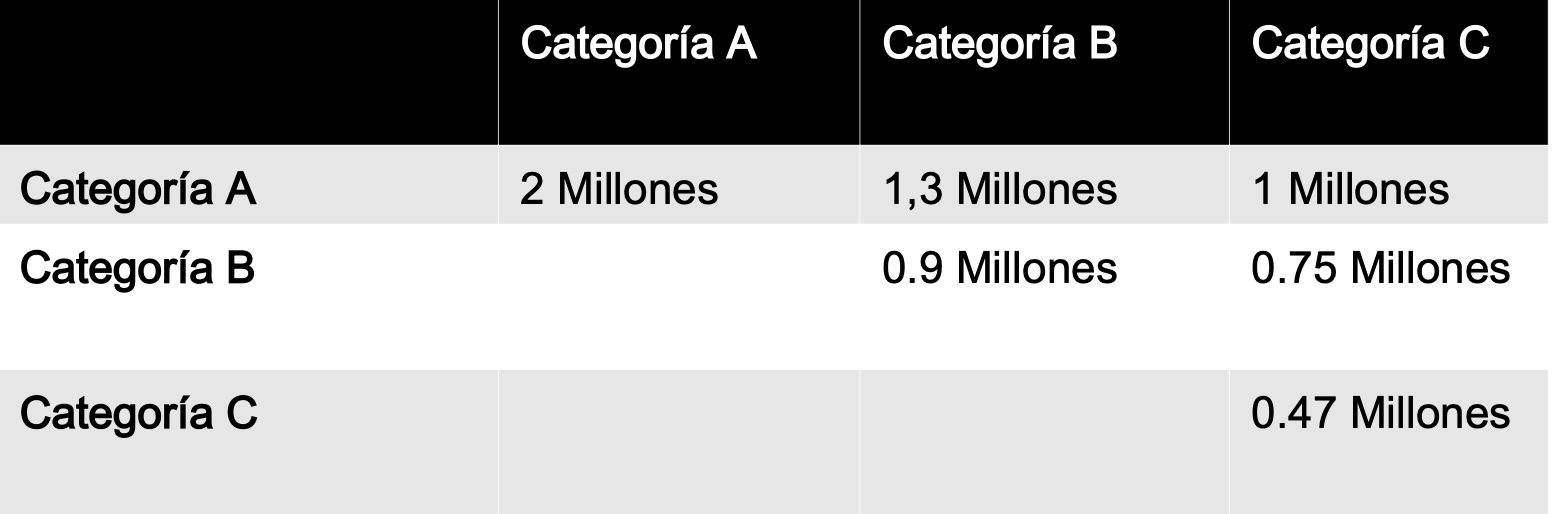

* Si el horario del partido no se realiza a las 20 horas del sábado se sabe que se reduce según los coeficientes de la siguiente tabla

* Debemos asignar obligatoriamente siempre un partido el viernes y un partido el lunes

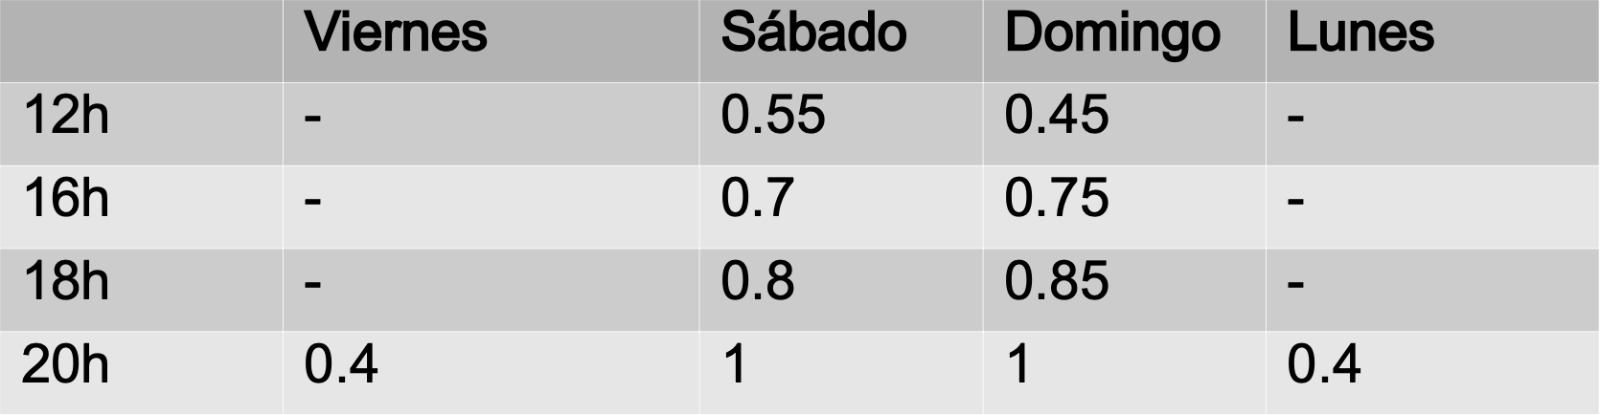


* Es posible la coincidencia de horarios pero en este caso la audiencia de cada partido se verá afectada y se estima que se reduce en porcentaje según la siguiente tabla dependiendo del número de coincidencias:

<br>
<center>
<table style="width:100%; height:200px font-size:20px; text-align:center; border-collapse:collapse; border:2px solid black;">
  <tr style="background-color:#4CAF50; color:white;">
    <th style="padding:15px; border:2px solid black;">Coincidencias</th>
    <th style="padding:15px; border:2px solid black;">-%</th>
  </tr>
  <tr>
    <td style="padding:12px; border:2px solid black;">0</td>
    <td style="padding:12px; border:2px solid black;">0%</td>
  </tr>
  <tr>
    <td style="padding:12px; border:2px solid black;">1</td>
    <td style="padding:12px; border:2px solid black;">25%</td>
  </tr>
  <tr>
    <td style="padding:12px; border:2px solid black;">2</td>
    <td style="padding:12px; border:2px solid black;">45%</td>
  </tr>
  <tr>
    <td style="padding:12px; border:2px solid black;">3</td>
    <td style="padding:12px; border:2px solid black;">60%</td>
  </tr>
    <tr>
    <td style="padding:12px; border:2px solid black;">4</td>
    <td style="padding:12px; border:2px solid black;">70%</td>
  </tr>
    <tr>
    <td style="padding:12px; border:2px solid black;">5</td>
    <td style="padding:12px; border:2px solid black;">75%</td>
  </tr>
    <tr>
    <td style="padding:12px; border:2px solid black;">6</td>
    <td style="padding:12px; border:2px solid black;">78%</td>
  </tr>
    <tr>
    <td style="padding:12px; border:2px solid black;">7</td>
    <td style="padding:12px; border:2px solid black;">80%</td>
  </tr>
    <tr>
    <td style="padding:12px; border:2px solid black;">8</td>
    <td style="padding:12px; border:2px solid black;">80%</td>
  </tr>
</table>
</center>
<br>


* Los cálculos asociados a una jornada de ejemplo se realizan según se muestra en la siguiente tabla:

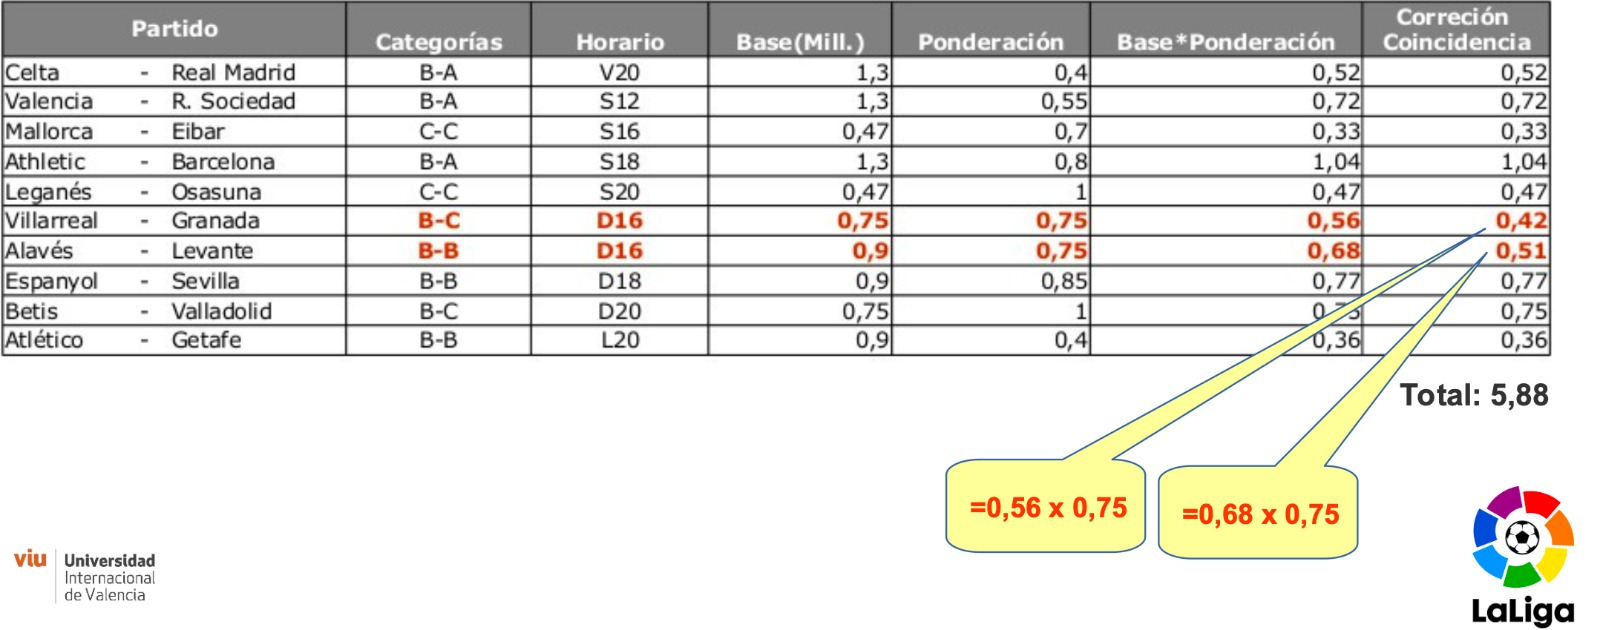

#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

Para poder representar el espacio de soluciones debemos de tener en cuenta todas las variables descritas en el enunciado y sujetas a que condiciones se encuentran estas variables para poder modelar el objetivo que se esta pidiendo optimizar. A continuación se describe cada uno de los requerimientos del problema:
* Tenemos un arreglo de horarios, para este caso en particular tenemos 10 slots de horarios V20, S12, S16, S18, S20, D12, D16, D18, D20 y L20 lo cuales pueden ser representados por el arreglo horarios, h:

```
h = [0,1,2,3,4,5,6,7,8,9]
```
* También se nos menciona 20 equipos de los cuales 3 pertenecen a la categoría A, 11 a la categoría B y 6 a la categoría C.
Esto se puede modelar también como un arreglo de equipos Ai, Bj, Ck:

```
equipos = ["A1", "A2", "A3", "B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B9", "B10", "B11", "C1", "C2", "C3", "C4", "C5", "C6"]
```

* Por otro, lado tenemos los arreglos de ganancias base, factor de ganancia por horario y la penalización de concurrencia (Por conveniencia llamaremos penalización por número de partidos en un mismo horario)

Matriz de ganancias base:
```
matriz_ganancias={"AA":2,"AB":1.3,"AC":1,"BA":1.3,"BB":0.9,"BC":0.75,"CA":1,"CB":0.75,"CC":0.47}
```
Factor de ganancia por horario:
```
factor_ganancia_horaria = [0.4,0.55,0.7,0.8,1,0.45,0.75,0.85,1,0.4]
```
Penalización por número de partidos en un mismo horario:
```
penalizacion_numero_partidos={0:0, 1:0, 2:-0.25, 3:-0.45, 4:-0.60, 5: -0.70, 6: -0.75, 7: -0.78, 8: -0.80, 9: -0.80}
```
Habiendo definido nuestro grupo de variables primarias, podemos iniciar modelando el espacio de soluciones, para esto primero necesitamos conocer todas las combinaciones posibles de pares de equipos que podemos formar en el arreglo de equipos, para uso usaremos la herramienta itertools para obtener dichas combinaciones.
```
partidos = list(itertools.combinations(equipos, 2))
```
Esto como veremos en su implementación en python nos dará un total de 190 combinaciones

$$\binom{20}{2} = \frac{20!}{2!(20-2)!}=190$$

Con esto en mente tenemos todos los partidos posibles que podemos formar con esos equipos, lo cual nos servirá como base para modelar la primera dimensión de nuestro espacio de soluciones. Debemos tener en cuenta que a cada uno de estas combinaciones por partido se le atribuye una banancia base que estará dada por la forma en como esta combinada la tupla según la matriz **matriz_ganancias**, que lo usaremos en breve en la implementación.
Nuestro objetivo principal es optimizar la ganancia total de audiencia en base a la planificación y asignación de los partidos de futbol a estos horarios, sujeto a las condiciones previamente descritas. También se esta tomando en consideración que un equipo juega 1 sola vez en su jornada, según el ejemplo propuesto.

¿Cómo represento el espacio de soluciones?

Ahora estas 190 combinaciones de partidos diferentes pueden ser asignados a cualquiera de los horarios, en este caso no lo modelaremos en base a variaciones matemáticas donde el slot subsiguiente se le podría asignar una cantidad igual a uno menos que el anterior, en vez de eso tendremos dos dimensiones una de los horarios y otra de los partidos, en el que se tendrá su producto cartesianos y su activación de estos indicarán si son los seleccionados para poder optimizar la ganancia de la audiencia. Es decir tendremos una matriz decisoria de todas asociaciones (producto cartesiano) entre los horarios (eje y) y partidos (eje x) obtenidos hasta el momento, de tal forma que algunos estén activos e inactivos aplicando las ganancias base y el factor de ganancia por horario podamos obtener la ganancia total de audiencia. Esto sería en un mundo ideal donde la coincidencia de los partidos en un mismo horario no afectaría el fraccionamiento de la audiencia, pero como en el problema se está considerando también esta penalización, también debemos tener en cuenta que a medida que vamos acumulando partidos en un mismo horario se va fragmentando la audiencia (esto afecta dinámicamente a la ganancia (Eje z)). Es así que el enfoque de la solución del problema los podemos dividir en dos, representado por la función objetivo a optimizar f(x,penalizacion):

¿Cuál es la función objetivo?
$$f(x,penalizacion)=x'(p,h)+penalizacion'(p,h)$$
donde:
$$x'(p,h)= x(p, h) * ganancias\_base(p) * factor\_ganancia\_horaria(h)$$
y
$$penalizacion'(p,h)= penalizacion(h)* ganancias\_base(p) * factor\_ganancia\_horaria(h)$$

p: es la variable que se refiere al partido, h: es la variable que se refiere al horario.
En este caso penalización es un conjunto de variables inducidas a partir de la cantidad de partidos planificados en un mismo horario, sujeto a restricciones que justamente cumplan esa lógica.
Por lo tanto teniendo en cuenta todo esto, el espacio de soluciones queda representado como una combinación lineal de variables decisorias binarias represntadas a su vez por x(p,h) con un total de 1900 variables (190 (combinaciones de partidos multiplicado por la cantidad de horarios) sumado con las penalizaciones respectivas obtenidas de fragmentar la audiencia al acumular partidos en un mismo horario.

El problema se puede modelar en la forma de resolución de un problema mediante programación lineal entera:

$$\begin{array}{rclll}
\max & c_1 x_1 + c_2 x_2  +\cdots + c_n x_n & & &\text{linear function of decision variables} \\
\mathsf{s.t.} & a_{11} x_1 + a_{12} x_2 + \cdots + a_{1n} x_n & \leq & b_1 & \text{Constr. 1} \\
& a_{21} x_1 + a_{22} x_2 + \cdots + a_{2n} x_n & \leq & b_2 & \text{Constr.  2} \\
& \ddots & & \vdots \\
& a_{m1} x_1 + a_{m2} x_2 + \cdots + a_{mn} x_n & \leq & b_m & \text{Constr.  m}\\
\end{array}$$

Los puntos claves son :
  - Las variables de desición toman valores binarios, tanto **x** como **penalizacion**.
  - La función objetivo es lineal (nosotros podemos multiplicar a las variables de decisión por algunos factores constantes y agregarlas entre sí)
  - Las restricciones son desigualdades o igualdades lineales: comparan una función lineal sobre variables de decision con constantes.

¿Cómo implemento las restricciones?

A continuación describiremos cada una de las restricciones para llevar a cabo la resolución del problema y luego la llevaremos cabo en su implementación:

- Cada equipo juega una única vez en cada jornada de futbol
- El primer horario al menos debe tener un partido planificado
- El último horario al menos debe tener un partido planificado
- Cada partido puede solo ser asignado a un único horario

Para restriccions auxiliares:

- Se considera un conjunto de variables auxiliares (cado uno por horario) cuyo valor debe ser igual a la suma acumulada del número de partidos por horario
- Para un determinado horario solo se puede tener a lo mucho una única penalización, es decir no se puede penalizar por concurrencia de 2 y a la vez también de 3, eso no es consistente
- Se crea las variables decisorias de penalización cuyo valor será igual a la penalización obtenida en cada horario
- El valor de cada variable decisoria binarias de penalización por horario multiplicado por el número de veces que juega el equipo para esa misma variable debe ser igual al valor de partidos acumulados en ese horario



In [4]:
#instalación de la librería PuLP
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 57.1 MB/s eta 0:00:00


In [5]:
#Importación de librerías
from pulp import LpMaximize, LpProblem, LpVariable, lpSum, LpSolverDefault, PULP_CBC_CMD
import math
import itertools
import time

In [6]:
#Definición de variables iniciales
horarios = list(range(10)) #Definimos la lista de horarios de los partidos de futbol el 0 y el 9 deben tener al menos un partido planificado
equipos = ["A1", "A2", "A3", "B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B9", "B10", "B11", "C1", "C2", "C3", "C4", "C5", "C6"]
partidos = list(itertools.combinations(equipos, 2))
ganancias_base = dict()
matriz_ganancias={"AA":2,"AB":1.3,"AC":1,"BA":1.3,"BB":0.9,"BC":0.75,"CA":1,"CB":0.75,"CC":0.47}
factor_ganancia_horaria = [0.4,0.55,0.7,0.8,1,0.45,0.75,0.85,1,0.4]
penalizacion_numero_partidos={0:0, 1:0, 2:-0.25, 3:-0.45, 4:-0.60, 5: -0.70, 6: -0.75, 7: -0.78, 8: -0.80, 9: -0.80, 10: -0.90}

In [7]:
print(f"Se tiene un total de {len(partidos)} partidos posibles")
# Obtenemos el arreglo de ganancias base (dependiente del partido jugado)
for partido in partidos:  # Mostrar solo los primeros 10
    categoria1 = partido[0][0:1]
    categoria2 = partido[1][0:1]
    ganancia_key = categoria1 + categoria2
    ganancia = matriz_ganancias.get(ganancia_key)
    ganancias_base[partido] = ganancia
ganancias_base

Se tiene un total de 190 partidos posibles


{('A1', 'A2'): 2,
 ('A1', 'A3'): 2,
 ('A1', 'B1'): 1.3,
 ('A1', 'B2'): 1.3,
 ('A1', 'B3'): 1.3,
 ('A1', 'B4'): 1.3,
 ('A1', 'B5'): 1.3,
 ('A1', 'B6'): 1.3,
 ('A1', 'B7'): 1.3,
 ('A1', 'B8'): 1.3,
 ('A1', 'B9'): 1.3,
 ('A1', 'B10'): 1.3,
 ('A1', 'B11'): 1.3,
 ('A1', 'C1'): 1,
 ('A1', 'C2'): 1,
 ('A1', 'C3'): 1,
 ('A1', 'C4'): 1,
 ('A1', 'C5'): 1,
 ('A1', 'C6'): 1,
 ('A2', 'A3'): 2,
 ('A2', 'B1'): 1.3,
 ('A2', 'B2'): 1.3,
 ('A2', 'B3'): 1.3,
 ('A2', 'B4'): 1.3,
 ('A2', 'B5'): 1.3,
 ('A2', 'B6'): 1.3,
 ('A2', 'B7'): 1.3,
 ('A2', 'B8'): 1.3,
 ('A2', 'B9'): 1.3,
 ('A2', 'B10'): 1.3,
 ('A2', 'B11'): 1.3,
 ('A2', 'C1'): 1,
 ('A2', 'C2'): 1,
 ('A2', 'C3'): 1,
 ('A2', 'C4'): 1,
 ('A2', 'C5'): 1,
 ('A2', 'C6'): 1,
 ('A3', 'B1'): 1.3,
 ('A3', 'B2'): 1.3,
 ('A3', 'B3'): 1.3,
 ('A3', 'B4'): 1.3,
 ('A3', 'B5'): 1.3,
 ('A3', 'B6'): 1.3,
 ('A3', 'B7'): 1.3,
 ('A3', 'B8'): 1.3,
 ('A3', 'B9'): 1.3,
 ('A3', 'B10'): 1.3,
 ('A3', 'B11'): 1.3,
 ('A3', 'C1'): 1,
 ('A3', 'C2'): 1,
 ('A3', 'C3'): 1,
 ('A3', 'C

#Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones

Para la parte del modelo sin penalización,en este caso el conjunto de variables decisorias x(p,h) como conjunto de variables binarias formadas por el producto cartesiano de las combinaciones de los equipos (partidos) y el conjunto de los horarios, tenemos un total de 1900 variables decisorias binarias, lo cuales se usarán en la combinación lineal de la función objetivo sin aplicar penalizaciones por acumulación de partido en un mismo horario.
Para el caso del modelo de penalización tenemos un conjunto de variables de decisión igual al producto cartesiano del número de horario asociado con los tipos penalizaciones (cantidad de partidos acumulados en el mismo horario), si tenemos en cuenta que tenemos 10 horarios y 10 penalizaciones, entonces eso nos da un total de 100 variables de decisión. Ademas debemos tener en cuenta las variables de decisión auxiliares, tenemos las variables de acumulación de partidos por horario (10 variables) y las variable final de penalización (la cual se usará en la ecuación de la función objetivo) cuya cantidad es tambien de 10. Con todo esta cantidad de variables tenemos un total de 2020 variables de decisión que se usan para modelar el algoritmo por programación lineal. Ahora el algoritmo que esta usando la librería PuLP que usaremos en la implementación es del tipo de PULP-CBC-CMD, basado en el algoritmo de ramificación y poda, en el cual se puede tener un orden de complejidad polinomial para problemas medianos hasta orden exponencial para problemas más complejos. Ahora si intentamos resolverlo por fuerza bruta, en cada uno de los horarios vamos asignando cualquiera de los partidos, partiendo desde el primer horario que le correspondería 190 posibilidades y asi sucesivamente hasta el ultimo horario, tendríamos:

$$
V(n, k) = \frac{n!}{(n-k)!} = \frac{190!}{(190-10)!} = 48185726264779149446400
$$

el cual es bastante grande y eso asumiendo que en cada horario asignaremos solo un partido para evitar alguna penalización y complicación adicional.

In [1]:
#Respuesta
from scipy.special import perm

n = 190
k = 10

variaciones = perm(n, k, exact=True)
print(variaciones)

48185726264779149446400


#Diseño
- ¿Que técnica utilizo? ¿Por qué?

Ahora teniendo en cuenta todo la carga computacional que nos llevaría haciendo uso de un algoritmo por fuerza bruta, la cantidad de restricciones, la función a optimizar y sobre todo la capacidad para modelar este problema de manera lineal, entonces el algortimo utilizado será la programación lineal, el cual haremos uso de la librería PuLP, que es una de las librerías más usadas para la programación lineal debido a su eficiencia para poder resolver estos problemas. Esta librería permite resolver problemas con varias variables de decisión incluso llegar al millón de variables y restricciones, resolviendo el problema de manera eficiente.

In [11]:
#procedemos a crear el modelo
modelo = LpProblem("Problema_planificacion_partidos_LaLiga", LpMaximize)

In [12]:
#Variables de decision
#Definimos las variables x del tipo binaria que asocia la dimensión de partidos con la de horarios
x = {(p,h) : LpVariable(f"x_p{p}_h{h}",cat="Binary")  for p in partidos for h in horarios}
# Definimos la variable auxiliar acumuladora de partidos por horario
c = {h : LpVariable(f"c_h{h}",cat="Integer",lowBound=0) for h in horarios}
# Definimos la variable auxiliar ps selector de penalización por horario como aquella que se forma con las diferentes asociaciones entre horario y tipo de penalización
ps = {(h,np) : LpVariable(f"ps_h{h}_p{np}",cat="Binary") for np in penalizacion_numero_partidos.keys() for h in horarios}
# Definimos la variable de decision penalizacion el cual tendra las posibles penalizaciones por horario debido a la acumulacion de partidos en un mismo horario
penalizacion = {h : LpVariable(f"penalizacion_h{h}",lowBound=0) for h in horarios}

In [13]:
#Definicion de restricciones base
# 1. Cada equipo juega una única vez en cada jornada de futbol ¿Cuantas restricciones debo crear? 1 por cada equipo, este debe ser valido en todo el espacio de asociaciones (20 restricciones)
for e in equipos:
  modelo +=  lpSum(x[(p,h)] for h in horarios for p in partidos if e in p)  == 1

# 2. El primer horario al menos debe tener un partido planificado
modelo += lpSum(x[(p,0)] for p in partidos) >= 1

# 3. El último horario al menos debe tener un partido planificado
modelo += lpSum(x[(p,9)] for p in partidos) >= 1

# 4. Cada partido puede solo ser asignado a lo mas a un único horario ¿Cuantas restricciones debo crear? 1 por cada partido, en total 190 restricciones
for p in partidos:
  modelo += lpSum(x[(p,h)] for h in horarios) <= 1

In [14]:
# Definicion de restricciones auxiliares
# 5. Se considera un conjunto de variables auxiliares (cado uno por horario) cuyo valor debe ser igual a la suma acumulada del número de partidos por horario
for h in horarios:
  modelo += c[h] == lpSum(x[(p,h)] for p in partidos)
# 6. Para un determinado horario solo se puede tener a lo mucho una única penalización, es decir no se puede penalizar por concurrencia de 2 y a la vez también de 3, eso no es consistente
for h in horarios:
  modelo += lpSum(ps[(h,np)] for np in penalizacion_numero_partidos.keys()) == 1
# 7. Se crea las variables decisorias de penalización cuyo valor será igual a la penalización obtenida en cada horario
  modelo += penalizacion[h] == lpSum(ps[h,np] * pe for np, pe in penalizacion_numero_partidos.items())
# 8. El valor de cada variable decisoria binaria de penalización por horario multiplicado por el número de veces que juega el equipo para esa misma variable debe ser igual al valor de partidos acumulados en ese horario
  modelo += c[h] == lpSum(ps[h,np] * np for np in penalizacion_numero_partidos.keys())

In [15]:
# Función Objetivo: Maximizar ganancia ajustada por horario y concurrencia
modelo += lpSum(x[(p, h)] * ganancias_base.get(p, 0) * factor_ganancia_horaria[h] + penalizacion[h] * ganancias_base.get(p, 0) * factor_ganancia_horaria[h]
                for p in partidos for h in horarios)
print("Solver utilizado:", LpSolverDefault.msg)
start_time = time.time()
# Resolver el modelo
modelo.solve()
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.4f} segundos")

Solver utilizado: True
Tiempo de ejecución: 0.2247 segundos


In [16]:
# Mostrar resultados
for p in partidos:
    for h in horarios:
        if x[(p, h)].value() == 1:
            print(f"Partido {p} asignado al horario {h}")

Partido ('A1', 'A2') asignado al horario 8
Partido ('A3', 'B8') asignado al horario 4
Partido ('B1', 'C5') asignado al horario 1
Partido ('B2', 'B11') asignado al horario 3
Partido ('B3', 'B5') asignado al horario 6
Partido ('B4', 'C6') asignado al horario 5
Partido ('B6', 'C1') asignado al horario 0
Partido ('B7', 'B10') asignado al horario 7
Partido ('B9', 'C2') asignado al horario 2
Partido ('C3', 'C4') asignado al horario 9


In [17]:
print(modelo.objective.value())

7.223
